<a href="https://colab.research.google.com/github/Poluneniharika/Amazon-clone-project/blob/main/Copy_of_Untitled11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle xgboost imbalanced-learn seaborn tensorflow scikit-learn matplotlib pandas

In [ ]:
from google.colab import files
print("👉 Please upload your kaggle.json file now.")
uploaded = files.upload()

👉 Please upload your kaggle.json file now.


Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip > /dev/null
print("✅ Dataset downloaded and extracted!")


Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 870MB/s]
✅ Dataset downloaded and extracted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
df = pd.read_csv('creditcard.csv')
print("✅ Data Loaded Successfully!")
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['Class'].value_counts())

✅ Data Loaded Successfully!
Shape: (284807, 31)

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ⚠️ Use partial SMOTE (not full) for speed
X_part, _, y_part, _ = train_test_split(X_scaled, y, train_size=0.25, stratify=y, random_state=42)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_part, y_part)
print("\nAfter partial SMOTE balancing:", np.bincount(y_res))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)


After partial SMOTE balancing: [71078 71078]


In [ ]:
lr = LogisticRegression(max_iter=500, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("\n🔹 Logistic Regression Results")
print(classification_report(y_test, y_pred_lr, zero_division=0))



🔹 Logistic Regression Results
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     14194
           1       0.98      0.97      0.97     14238

    accuracy                           0.97     28432
   macro avg       0.97      0.97      0.97     28432
weighted avg       0.97      0.97      0.97     28432



In [ ]:
rf = RandomForestClassifier(
    n_estimators=50,         # fewer trees for speed
    max_depth=10,            # limit depth
    class_weight='balanced', # handle imbalance
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n🔹 Random Forest Results")
print(classification_report(y_test, y_pred_rf, zero_division=0))



🔹 Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14194
           1       1.00      1.00      1.00     14238

    accuracy                           1.00     28432
   macro avg       1.00      1.00      1.00     28432
weighted avg       1.00      1.00      1.00     28432



In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("\n🔹 XGBoost Results")
print(classification_report(y_test, y_pred_xgb, zero_division=0))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:32:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14194
           1       1.00      1.00      1.00     14238

    accuracy                           1.00     28432
   macro avg       1.00      1.00      1.00     28432
weighted avg       1.00      1.00      1.00     28432



In [12]:
model = Sequential([
    Dense(32, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=1024, validation_split=0.2, verbose=1)

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("\n🔹 Neural Network Results")
print(classification_report(y_test, y_pred_nn, zero_division=0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6412 - loss: 0.8220 - val_accuracy: 0.9600 - val_loss: 0.1931
Epoch 2/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9457 - loss: 0.1889 - val_accuracy: 0.9744 - val_loss: 0.0892
Epoch 3/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9666 - loss: 0.1035 - val_accuracy: 0.9847 - val_loss: 0.0541
Epoch 4/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9785 - loss: 0.0677 - val_accuracy: 0.9913 - val_loss: 0.0364
Epoch 5/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9858 - loss: 0.0487 - val_accuracy: 0.9952 - val_loss: 0.0268
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

🔹 Neural Network Results
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     14194
           1       0.99      1.00      1.00     14238

    accuracy                           1.00     28432
   macro avg       1.00      1.00      1.00     28432
weighted avg       1.00      1.

/tmp/ipykernel_1063/3165450494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


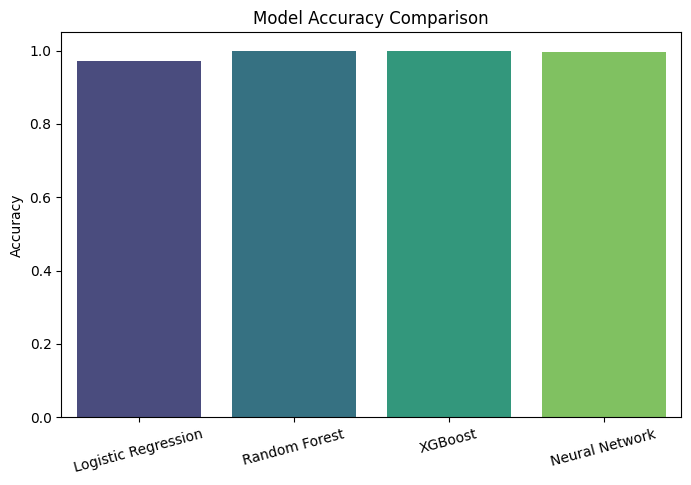

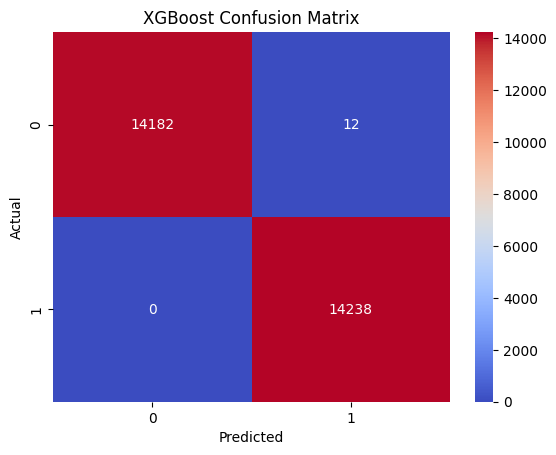

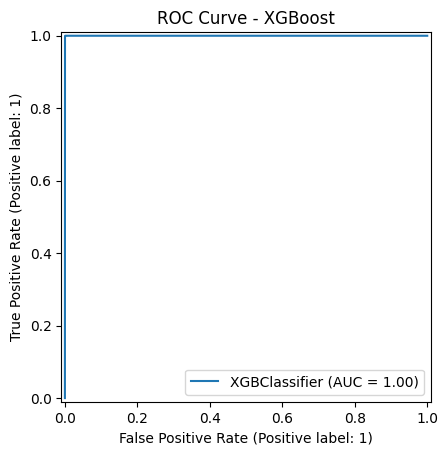

✅ All models trained and evaluated successfully!


In [13]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_nn)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

# Confusion Matrix (XGBoost Example)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()

print("✅ All models trained and evaluated successfully!")